# Algerian Forest Fires Analysis  

Forest fires are one of the most destructive environmental disasters affecting ecosystems, wildlife, and human life. Understanding the environmental and meteorological factors that influence fire risk is therefore extremely important.

In this study, the **Algerian Forest Fires Dataset** is analyzed. This dataset contains meteorological and fire-related observations recorded in two different regions of Algeria.

The dataset includes meteorological variables such as temperature, relative humidity, wind speed, and rainfall, as well as several fire danger indices used to measure wildfire risk.

The fire danger indices included in the dataset are:

- FFMC (Fine Fuel Moisture Code)
- DMC (Duff Moisture Code)
- DC (Drought Code)
- ISI (Initial Spread Index)
- BUI (Build Up Index)
- FWI (Fire Weather Index)

The main objective of this study is to develop machine learning models that can predict the **Fire Weather Index (FWI)** using meteorological variables.

# 1. Dataset Overview

In this section, the dataset was loaded and an initial inspection was performed to understand its structure. The dataset was read using the Pandas library, and the first rows were examined using the `head()` function.

Then, the `columns` and `info()` functions were used to analyze the variables in the dataset, their data types, and the overall structure of the dataset. During this inspection, it was observed that all columns were initially stored as **object data types**.

Finally, the `isnull()` function was used to check for **missing values**, and it was identified that some rows contained missing or invalid data.

This initial exploration helped to understand the dataset structure and provided the necessary information for the **data cleaning and preprocessing steps** that will be performed in the following stages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv("/kaggle/input/datasets/nitinchoudhary012/algerian-forest-fires-dataset/Algerian_forest_fires_dataset.csv")

In [4]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [5]:
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  '],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.1+ KB


In [7]:
df.isnull().sum()

day            1
month          2
year           2
Temperature    2
 RH            2
 Ws            2
Rain           2
FFMC           2
DMC            2
DC             2
ISI            2
BUI            2
FWI            2
Classes        3
dtype: int64

In [8]:
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [9]:
df.shape

(247, 14)

# 2. Target Variable Cleaning and Encoding

In this step, the dataset was cleaned and prepared for analysis and modeling. Since the dataset contains records from two different regions, a new feature called Region was created. The first part of the dataset was labeled as 0 and the second part as 1, allowing future analysis to be performed on a regional basis.

During preprocessing, missing values were removed and column names were standardized by removing unnecessary whitespace. An invalid row containing repeated column names was also identified in the day column and removed from the dataset. After cleaning, relevant columns were converted to appropriate numeric data types.

Finally, the target variable Classes was cleaned and encoded into binary form:

0 → not fire

1 → fire

After encoding, the class distribution shows approximately 56.4% fire and 43.6% not fire, indicating a relatively balanced dataset.

In [10]:
df.drop(122, inplace=True)

In [11]:
df.loc[:123,"Region"]= 0
df.loc[123:,"Region"]= 1

In [12]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0.0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0.0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0.0


In [13]:
df = df.dropna().reset_index(drop=True)

In [14]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [15]:
df.columns = df.columns.str.strip()

In [16]:
df["day"].unique()

array(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23',
       '24', '25', '26', '27', '28', '29', '30', '31', 'day'],
      dtype=object)

In [17]:
df[df["day"] == "day"]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1.0


In [18]:
df.drop(122, inplace=True)

In [19]:
df[["day","month", "year", "Temparature", "RH", "Ws"]] = df[["day","month", "year", "Temperature", "RH", "Ws"]].astype(int)

In [20]:
df[['Rain', 'FFMC', 'DMC','DC', 'ISI', 'BUI', 'FWI']] = df[['Rain', 'FFMC', 'DMC','DC', 'ISI', 'BUI', 'FWI']].astype(float)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243 entries, 0 to 243
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    object 
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    float64
 15  Temparature  243 non-null    int64  
dtypes: float64(8), int64(6), object(2)
memory usage: 32.3+ KB


In [22]:
df.describe()

,day,month,year,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region,Temparature
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,15.761317,7.502058,2012.0,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,0.497942,32.152263
std,8.842552,1.114793,0.0,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.501028,3.628039
min,1.000000,6.000000,2012.0,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000,22.000000
25%,8.000000,7.000000,2012.0,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000,30.000000
50%,16.000000,8.000000,2012.0,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,0.000000,32.000000
75%,23.000000,8.000000,2012.0,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.000000,35.000000
max,31.000000,9.000000,2012.0,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000,42.000000


In [23]:
df['Classes'].value_counts()
#BOŞLUKLARAN VE YANLIŞ YAZIMLARDAN KAYNAKLI BİR KAÇ TANE FARKLILILAR VAR GÖRÜLDÜĞÜ ÜZERE

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [24]:
df['Classes'] = np.where(df['Classes'].str.contains("not fire"), 0, 1)

In [25]:
df['Classes'].value_counts(normalize=True)

Classes
1    0.563786
0    0.436214
Name: proportion, dtype: float64

# 3. Exploratory Data Analysis

In this step, correlation analysis was performed to understand the relationships between variables and identify highly related features.

A correlation matrix was generated using df.corr() and visualized with a heatmap to examine how features interact with each other and with the target variable. This analysis helps reveal which variables move together and which ones may carry redundant information.

During the inspection, it was observed that the column Temparature is a duplicate of the Temperature feature, resulting in a perfect correlation (1.0). Such duplicated features do not add new information to the model and may cause multicollinearity issues, so they should typically be removed in later preprocessing steps.

Additionally, the temporal features day, month, and year were dropped from the dataset because they do not provide meaningful predictive information for this modeling stage.

Finally, the dataset was separated into independent features (X) and the target variable (y).
The variable FWI (Fire Weather Index) was selected as the target variable, while the remaining columns were used as input features for future modeling steps.

X → input features

y → target variable (FWI)

This separation prepares the dataset for the upcoming machine learning modeling phase.

In [26]:
df.corr()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region,Temparature
day,1.000000,-0.000369,NaN,0.097227,-0.076034,0.047812,-0.112523,0.224956,0.491514,0.527952,0.180543,0.517117,0.350781,0.202840,0.000821,0.097227
month,-0.000369,1.000000,NaN,-0.056781,-0.041252,-0.039880,0.034822,0.017030,0.067943,0.126511,0.065608,0.085073,0.082639,0.024004,0.001857,-0.056781
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Temperature,0.097227,-0.056781,NaN,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555,1.000000
RH,-0.076034,-0.041252,NaN,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682,-0.651400
Ws,0.047812,-0.039880,NaN,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160,-0.284510
Rain,-0.112523,0.034822,NaN,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013,-0.326492
FFMC,0.224956,0.017030,NaN,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241,0.676568
DMC,0.491514,0.067943,NaN,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089,0.485687
DC,0.527952,0.126511,NaN,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734,0.376284


<Axes: >

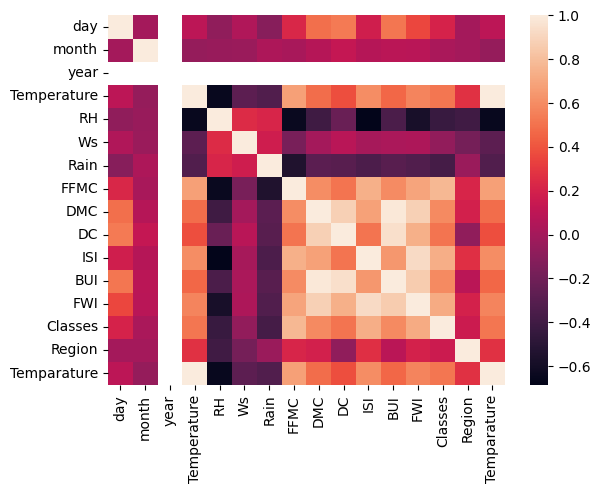

In [27]:
sns.heatmap(df.corr())

In [28]:
df.drop(['day', 'month','year'], axis = 1, inplace = True )

In [29]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region,Temparature
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0.0,29
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0.0,29
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0.0,26
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0.0,25
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0.0,27


In [30]:
# dependent & independent features

X = df.drop("FWI", axis=1)
y= df["FWI"]

In [31]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region,Temparature
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0.0,29
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0.0,29
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0.0,26
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0.0,25
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0.0,27


In [32]:
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
239    6.5
240    0.0
241    0.2
242    0.7
243    0.5
Name: FWI, Length: 243, dtype: float64

# 4. Model Preparation

## 4.1 Train-Test Split

In this step, the dataset is divided into training and testing sets.  
The model is trained using the training data, while its performance is evaluated on the test data.

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.25, random_state = 15)

In [35]:
X_train.shape

(182, 12)

## 4.2 Correlation Analysis

In this step, the correlation between the independent variables is analyzed.

The goal is to:

- identify features that are highly similar to each other  
- detect and prevent potential multicollinearity problems

In [36]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region,Temparature
Temperature,1.000000,-0.644824,-0.322405,-0.222809,0.600615,0.483815,0.362859,0.579809,0.452819,0.463959,0.229479,1.000000
RH,-0.644824,1.000000,0.205669,0.171031,-0.643767,-0.395535,-0.204568,-0.682107,-0.337032,-0.427947,-0.368402,-0.644824
Ws,-0.322405,0.205669,1.000000,0.152948,-0.135584,0.011874,0.104577,0.021616,0.051452,-0.044791,-0.181246,-0.322405
Rain,-0.222809,0.171031,0.152948,1.000000,-0.475600,-0.263007,-0.282983,-0.325552,-0.276457,-0.363013,0.049735,-0.222809
FFMC,0.600615,-0.643767,-0.135584,-0.475600,1.000000,0.592446,0.483610,0.732549,0.577031,0.770641,0.158505,0.600615
DMC,0.483815,-0.395535,0.011874,-0.263007,0.592446,1.000000,0.871387,0.658793,0.980646,0.549624,0.153781,0.483815
DC,0.362859,-0.204568,0.104577,-0.282983,0.483610,0.871387,1.000000,0.467977,0.939248,0.468011,-0.120874,0.362859
ISI,0.579809,-0.682107,0.021616,-0.325552,0.732549,0.658793,0.467977,1.000000,0.617313,0.714801,0.241664,0.579809
BUI,0.452819,-0.337032,0.051452,-0.276457,0.577031,0.980646,0.939248,0.617313,1.000000,0.550431,0.044453,0.452819
Classes,0.463959,-0.427947,-0.044791,-0.363013,0.770641,0.549624,0.468011,0.714801,0.550431,1.000000,0.136752,0.463959


If the correlation between two features is very high, one of them can be removed. 
When two variables are highly correlated, it means they carry very similar information. 
This leads to redundancy, meaning the model does not gain additional useful information from keeping both features.

High correlation between features may also cause multicollinearity. 
Multicollinearity can make model coefficients unstable, increase variance in the results, and reduce the model’s ability to generalize to new data. 
As a result, it may increase the risk of overfitting.

In practice, if the correlation between two features is above 0.95, one of them is usually removed. 
However, the final decision may also depend on domain knowledge. 
To systematically detect such features, we will write a small function that identifies highly correlated variables.
 

In [37]:
type(X_train.corr())

pandas.core.frame.DataFrame

In [38]:
print(X_train.corr().iloc[0,0])

1.0


## 4.3 Detecting Highly Correlated Features

If the correlation between two features is very high (typically above 0.95), one of them can be removed. 
Highly correlated features usually carry very similar information and may introduce redundancy into the model.

Therefore, we create a function to automatically detect highly correlated columns.

In [39]:
def correlation_for_dropping ( df, threshold):
    columns_to_drop = set()
    corr = df.corr()
    for i in range (len (corr.columns)):
        for j in range (i):    
              if abs(corr.iloc[i, j]) > threshold:
                 columns_to_drop.add( corr.columns[i])

    return columns_to_drop

## 4.4 Removing Highly Correlated Features

Using the defined function, highly correlated columns are identified and removed from the dataset.

In [40]:
columns_dropping = correlation_for_dropping(X_train, 0.95)
columns_dropping

{'BUI', 'Temparature'}

In [41]:
X_train.drop(columns_dropping, axis= 1, inplace = True)
X_test.drop(columns_dropping, axis= 1, inplace = True)

In [42]:
X_train.shape

(182, 10)

In [43]:
X_test.shape

(61, 10)

## 4.5 Feature Scaling

Many machine learning algorithms are sensitive to the scale of the features.  
Therefore, the variables are standardized using **StandardScaler**.

In [44]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [45]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<function matplotlib.pyplot.show(close=None, block=None)>

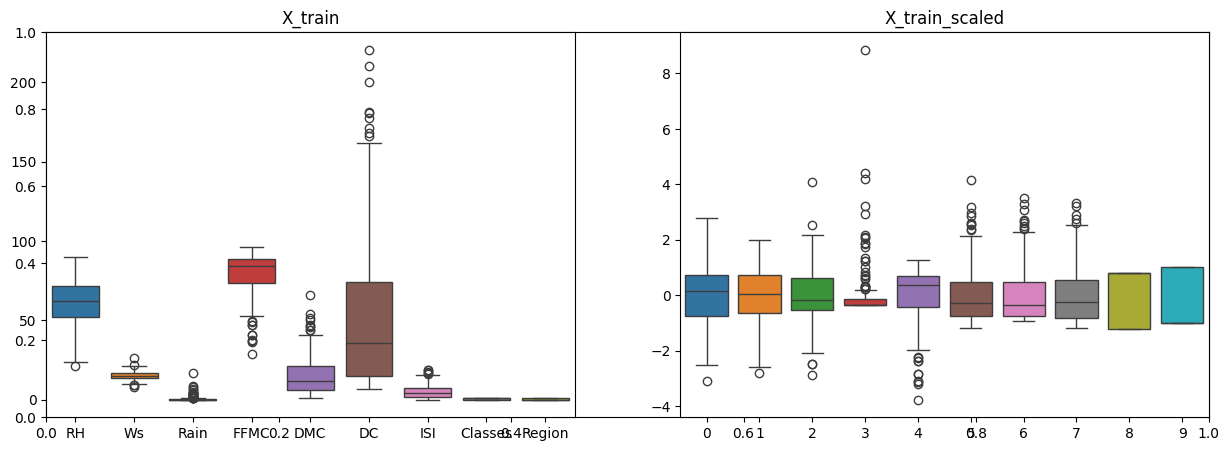

In [46]:
plt.subplots(figsize = (15,5))
plt.subplot(1,2,1)
sns.boxplot(data = X_train)
plt.title("X_train")
plt.subplot(1,2,2)
sns.boxplot(data = X_train_scaled)
plt.title("X_train_scaled")
plt.show

# 5. Regression Models

In this section, several regression algorithms are implemented and their performances are compared to evaluate how well they model the target variable.

## 5.1 Linear Regression

Linear Regression is one of the most basic and widely used regression algorithms. 
In this step, the model is trained using the scaled training data to predict the target variable. 
The model performance is then evaluated using metrics such as MAE, MSE, and R² score.

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Mean Absolute Error :  0.6482136286184251
Mean Squared Error: 0.7465583422386219
R2 Score : 0.9862624650807326


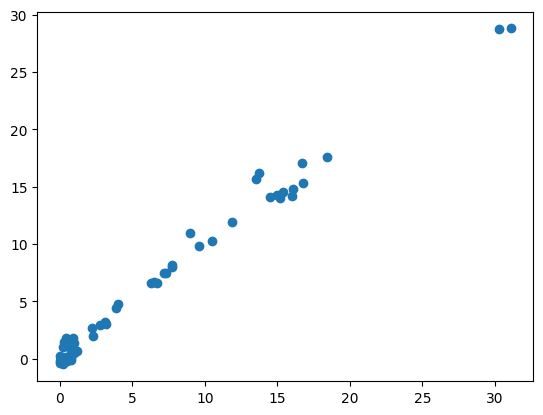

In [48]:
linear = LinearRegression()
linear.fit(X_train_scaled, y_train)
y_pred = linear.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absolute Error : ", mae)
print("Mean Squared Error:", mse)
print("R2 Score :", score)

plt.scatter(y_test, y_pred)
plt.show()

## 5.2 Lasso Regression

Lasso Regression applies **L1 regularization** to the linear model.  
This technique can shrink some feature coefficients to zero, which effectively performs **feature selection** by removing less important variables from the model.                          

Mean Absolute Error :  1.216272633800629
Mean Squared Error: 2.6029377368132187
R2 Score : 0.9521029422229386


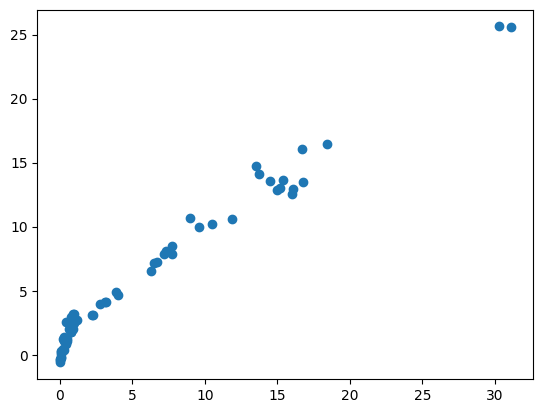

In [49]:
from sklearn.linear_model import Lasso 

lasso = Lasso()
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absolute Error : ", mae)
print("Mean Squared Error:", mse)
print("R2 Score :", score)

plt.scatter(y_test, y_pred)
plt.show()

### 5.3 Ridge Regression

Ridge Regression applies **L2 regularization** to the linear model.  
The main goal of this technique is to reduce overfitting by penalizing large coefficients and improving the model's ability to generalize.

Mean Absolute Error :  0.6509950839934143
Mean Squared Error: 0.7510440756968865
R2 Score : 0.9861799224092025


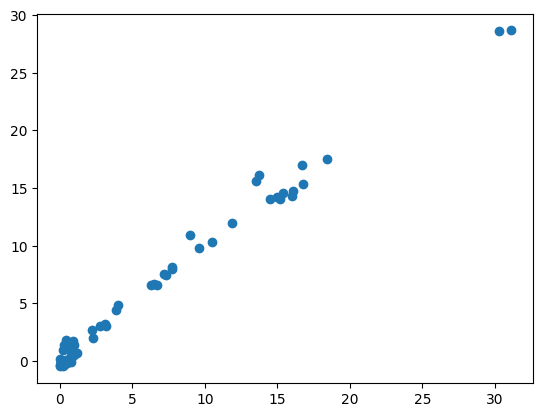

In [50]:
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absolute Error : ", mae)
print("Mean Squared Error:", mse)
print("R2 Score :", score)

plt.scatter(y_test, y_pred)
plt.show()

### 5.4 ElasticNet Regression

ElasticNet is a regularized regression model that combines both **L1 and L2 regularization**.  
It balances the benefits of Lasso and Ridge regression, helping to handle multicollinearity and reduce model complexity.

Mean Absolute Error :  1.563546711678729
Mean Squared Error: 4.701948809530433
R2 Score : 0.9134787165248952


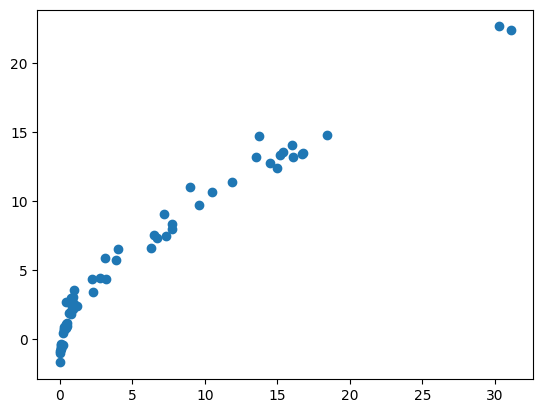

In [51]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet()
elastic.fit(X_train_scaled, y_train)
y_pred = elastic.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absolute Error : ", mae)
print("Mean Squared Error:", mse)
print("R2 Score :", score)

plt.scatter(y_test, y_pred)
plt.show()

## 6. Cross Validation and Hyperparameter Optimization

In regularization models, the **alpha** parameter significantly affects model performance.  
Therefore, cross-validation is used to find the optimal alpha value.

## 6.1 Lasso Cross Validation

LassoCV automatically tests multiple **alpha values** using cross-validation. 
It evaluates the model performance for different regularization strengths and selects the alpha value that provides the best overall performance.

Mean Absolute Error :  0.6588352261216767
Mean Squared Error: 0.7631408457077484
R2 Score : 0.9859573278830517


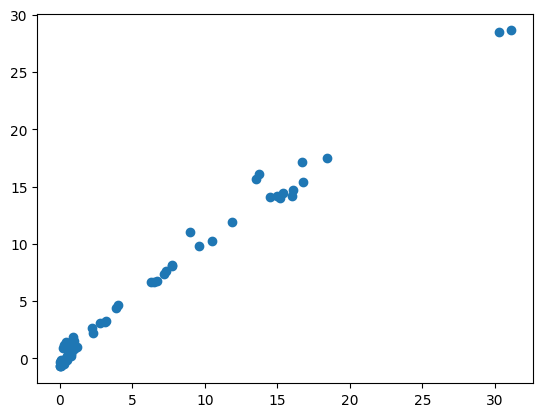

In [52]:
from sklearn.linear_model import LassoCV
lassocv = LassoCV(cv=5)
lassocv.fit(X_train_scaled, y_train)
y_pred = lassocv.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absolute Error : ", mae)
print("Mean Squared Error:", mse)
print("R2 Score :", score)

plt.scatter(y_test, y_pred)
plt.show()

In [53]:
lassocv.alpha_

np.float64(0.031548475118595085)

In [54]:
lassocv.alphas_

array([6.79691292, 6.33882374, 5.91160823, 5.51318562, 5.14161537,
       4.7950877 , 4.47191484, 4.17052274, 3.88944347, 3.627308  ,
       3.38283958, 3.15484751, 2.94222135, 2.74392548, 2.55899408,
       2.38652645, 2.22568255, 2.075679  , 1.93578518, 1.80531974,
       1.68364723, 1.57017504, 1.4643505 , 1.36565818, 1.27361739,
       1.18777984, 1.10772745, 1.03307033, 0.96344485, 0.89851189,
       0.83795519, 0.78147982, 0.72881069, 0.67969129, 0.63388237,
       0.59116082, 0.55131856, 0.51416154, 0.47950877, 0.44719148,
       0.41705227, 0.38894435, 0.3627308 , 0.33828396, 0.31548475,
       0.29422213, 0.27439255, 0.25589941, 0.23865264, 0.22256826,
       0.2075679 , 0.19357852, 0.18053197, 0.16836472, 0.1570175 ,
       0.14643505, 0.13656582, 0.12736174, 0.11877798, 0.11077275,
       0.10330703, 0.09634448, 0.08985119, 0.08379552, 0.07814798,
       0.07288107, 0.06796913, 0.06338824, 0.05911608, 0.05513186,
       0.05141615, 0.04795088, 0.04471915, 0.04170523, 0.03889

### 6.2 Ridge Cross Validation

RidgeCV performs cross-validation to automatically determine the optimal **alpha value** for Ridge Regression.  
It evaluates multiple regularization strengths and selects the alpha that results in the best model performance.

Mean Absolute Error :  0.6509950839934143
Mean Squared Error: 0.7510440756968865
R2 Score : 0.9861799224092025


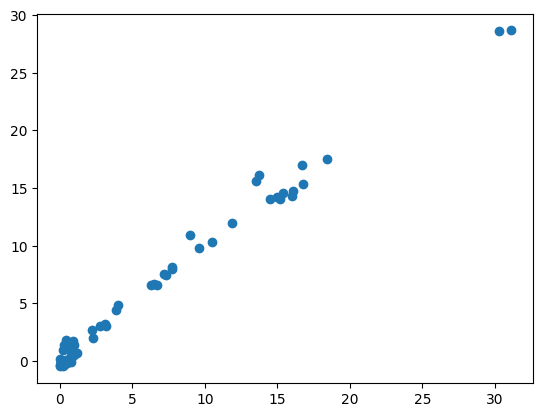

In [55]:
from sklearn.linear_model import RidgeCV
ridgecv = RidgeCV(cv=5)
ridgecv.fit(X_train_scaled, y_train)
y_pred = ridgecv.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absolute Error : ", mae)
print("Mean Squared Error:", mse)
print("R2 Score :", score)

plt.scatter(y_test, y_pred)
plt.show()

## 6.3 ElasticNet Cross Validation

ElasticNetCV uses cross-validation to automatically determine the optimal **alpha value** for the ElasticNet model.  
It evaluates multiple regularization strengths and selects the value that provides the best model performance.

In [ ]:
from sklearn.linear_model import ElasticNetCV
elasticnetcv = ElasticNetCV(cv=5)
elasticnetcv.fit(X_train_scaled, y_train)
y_pred = elasticnetcv.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absolute Error : ", mae)
print("Mean Squared Error:", mse)
print("R2 Score :", score)

plt.scatter(y_test, y_pred)
plt.show()

In [57]:
elasticnetcv.alpha_

np.float64(0.02215454901270056)

In [58]:
elasticnetcv.alphas_

array([13.59382584, 12.67764748, 11.82321647, 11.02637125, 10.28323073,
        9.5901754 ,  8.94382967,  8.34104549,  7.77888694,  7.25461599,
        6.76567915,  6.30969502,  5.8844427 ,  5.48785095,  5.11798817,
        4.77305289,  4.4513651 ,  4.15135799,  3.87157036,  3.61063947,
        3.36729446,  3.14035008,  2.928701  ,  2.73131635,  2.54723477,
        2.37555967,  2.2154549 ,  2.06614066,  1.92688969,  1.79702377,
        1.67591039,  1.56295964,  1.45762139,  1.35938258,  1.26776475,
        1.18232165,  1.10263712,  1.02832307,  0.95901754,  0.89438297,
        0.83410455,  0.77788869,  0.7254616 ,  0.67656792,  0.6309695 ,
        0.58844427,  0.5487851 ,  0.51179882,  0.47730529,  0.44513651,
        0.4151358 ,  0.38715704,  0.36106395,  0.33672945,  0.31403501,
        0.2928701 ,  0.27313164,  0.25472348,  0.23755597,  0.22154549,
        0.20661407,  0.19268897,  0.17970238,  0.16759104,  0.15629596,
        0.14576214,  0.13593826,  0.12677647,  0.11823216,  0.11

# 7. Model Results


In this study, several regression models were trained to predict the Fire Weather Index (FWI) using meteorological variables.

The models were evaluated using three common regression metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² Score.

The results show that Linear Regression and Ridge Regression achieved the best performance with an R² score of approximately 0.98. This indicates that the models were able to explain a large portion of the variance in the Fire Weather Index.

Lasso and ElasticNet regression models also performed well, but their performance was slightly lower due to the stronger regularization applied to the model coefficients.

Overall, the results suggest that meteorological variables are strong predictors of wildfire risk and can be effectively modeled using regression-based machine learning algorithms.